# 05 - Interpretación de Resultados y Recomendaciones de Negocio


Este notebook traduce los resultados técnicos obtenidos en el notebook de modelado a hallazgos interpretables para la institución educativa.  
Se mantiene la separación metodológica utilizada en el modelado:

- **K-Means** se utiliza como análisis complementario de segmentación.
- **Red Neuronal** y **Random Forest** se utilizan como modelos supervisados de clasificación para predecir la variable `Target_binary`.


## 5.1 Librerías e importaciones

In [35]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid", palette="muted")

PALETTE = ["#E84855", "#3BB273", "#F4A261", "#2E86AB"]

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)

print("Librerías cargadas correctamente")


Librerías cargadas correctamente


## 5.2 Carga del dataset procesado

Se utiliza el archivo `clean_dataset.csv`, generado en la etapa de preprocesamiento.  
La variable objetivo es `Target_binary`, donde:

- `1` representa estudiantes que abandonaron.
- `0` representa estudiantes que no abandonaron.


In [38]:
df = pd.read_csv("../data/processed/clean_dataset.csv")

print(f"Dataset: {df.shape[0]} estudiantes, {df.shape[1]} variables")
print(f"No abandono (0): {(df['Target_binary'] == 0).sum()}")
print(f"Abandono (1): {(df['Target_binary'] == 1).sum()}")

df.head(3)


Dataset: 4424 estudiantes, 35 variables
No abandono (0): 3003
Abandono (1): 1421


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target_binary
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1


## 5.3 Segmentación complementaria con K-Means

K-Means se utiliza como una herramienta de segmentación exploratoria.  
Su objetivo no es predecir directamente el abandono escolar, sino identificar grupos de estudiantes con características similares para complementar la interpretación del problema.

Para mantener consistencia con el notebook de modelado, se utilizan **3 clusters**.


In [39]:
X = df.drop(columns=["Target_binary"])
y = df["Target_binary"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_kmeans = pd.DataFrame(X_scaled, columns=X.columns)
X_kmeans = X_kmeans.replace([np.inf, -np.inf], np.nan)
X_kmeans = X_kmeans.fillna(0)
X_kmeans = X_kmeans.clip(lower=-10, upper=10)
X_kmeans = X_kmeans.astype(np.float64)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    kmeans = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10,
        init="random",
        algorithm="lloyd"
    )

    df["Cluster"] = kmeans.fit_predict(X_kmeans)

cluster_dropout = df.groupby("Cluster")["Target_binary"].mean().sort_values(ascending=False)

cluster_names = {}
ordered_clusters = list(cluster_dropout.index)

if len(ordered_clusters) >= 3:
    cluster_names[ordered_clusters[0]] = "Alto riesgo académico"
    cluster_names[ordered_clusters[1]] = "Riesgo intermedio"
    cluster_names[ordered_clusters[2]] = "Riesgo bajo"

df["Cluster_Name"] = df["Cluster"].map(cluster_names)

cluster_summary = df.groupby("Cluster_Name").agg(
    Estudiantes=("Target_binary", "count"),
    Tasa_Desercion=("Target_binary", "mean"),
    Edad_Promedio=("Age at enrollment", "mean"),
    Calificacion_1er_Sem=("Curricular units 1st sem (grade)", "mean"),
    Calificacion_2do_Sem=("Curricular units 2nd sem (grade)", "mean"),
    Materias_Aprobadas_1=("Curricular units 1st sem (approved)", "mean"),
    Materias_Aprobadas_2=("Curricular units 2nd sem (approved)", "mean"),
    Pct_Deudores=("Debtor", "mean"),
    Pct_Becados=("Scholarship holder", "mean")
).round(3)

cluster_summary["Desercion_%"] = (cluster_summary["Tasa_Desercion"] * 100).round(1)

cluster_summary.to_csv("../outputs/tables/cluster_summary.csv")

cluster_summary


,Estudiantes,Tasa_Desercion,Edad_Promedio,Calificacion_1er_Sem,Calificacion_2do_Sem,Materias_Aprobadas_1,Materias_Aprobadas_2,Pct_Deudores,Pct_Becados,Desercion_%
Cluster_Name,,,,,,,,,,
Alto riesgo académico,870,0.828,26.091,2.133,0.633,0.408,0.093,0.195,0.097,82.8
Riesgo bajo,3265,0.193,22.030,12.733,12.574,5.255,5.119,0.089,0.301,19.3
Riesgo intermedio,289,0.249,28.716,12.618,12.638,11.450,9.785,0.145,0.114,24.9


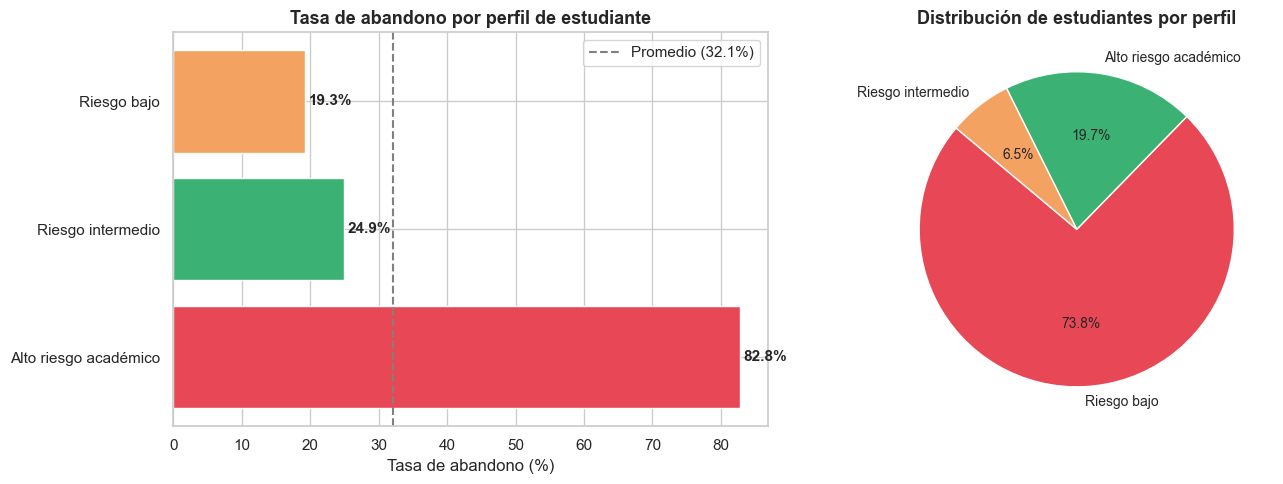

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_dropout_plot = df.groupby("Cluster_Name")["Target_binary"].mean().sort_values(ascending=False) * 100
bars = axes[0].barh(cluster_dropout_plot.index, cluster_dropout_plot.values, color=PALETTE[:len(cluster_dropout_plot)])
axes[0].set_xlabel("Tasa de abandono (%)")
axes[0].set_title("Tasa de abandono por perfil de estudiante", fontsize=13, fontweight="bold")

for bar, val in zip(bars, cluster_dropout_plot.values):
    axes[0].text(
        val + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

avg = df["Target_binary"].mean() * 100
axes[0].axvline(avg, color="gray", linestyle="--", label=f"Promedio ({avg:.1f}%)")
axes[0].legend()

cluster_size = df["Cluster_Name"].value_counts()
axes[1].pie(
    cluster_size.values,
    labels=cluster_size.index,
    autopct="%1.1f%%",
    colors=PALETTE[:len(cluster_size)],
    startangle=140,
    textprops={"fontsize": 10}
)
axes[1].set_title("Distribución de estudiantes por perfil", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/cluster_overview.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3.1 Interpretación de perfiles

La segmentación permite observar grupos con diferentes niveles de riesgo.  
Los perfiles con mayor tasa de abandono deben priorizarse para acciones de seguimiento académico, apoyo financiero y tutorías tempranas.

Esta segmentación no sustituye a los modelos supervisados, sino que aporta una lectura complementaria para entender mejor los tipos de estudiantes presentes en el dataset.


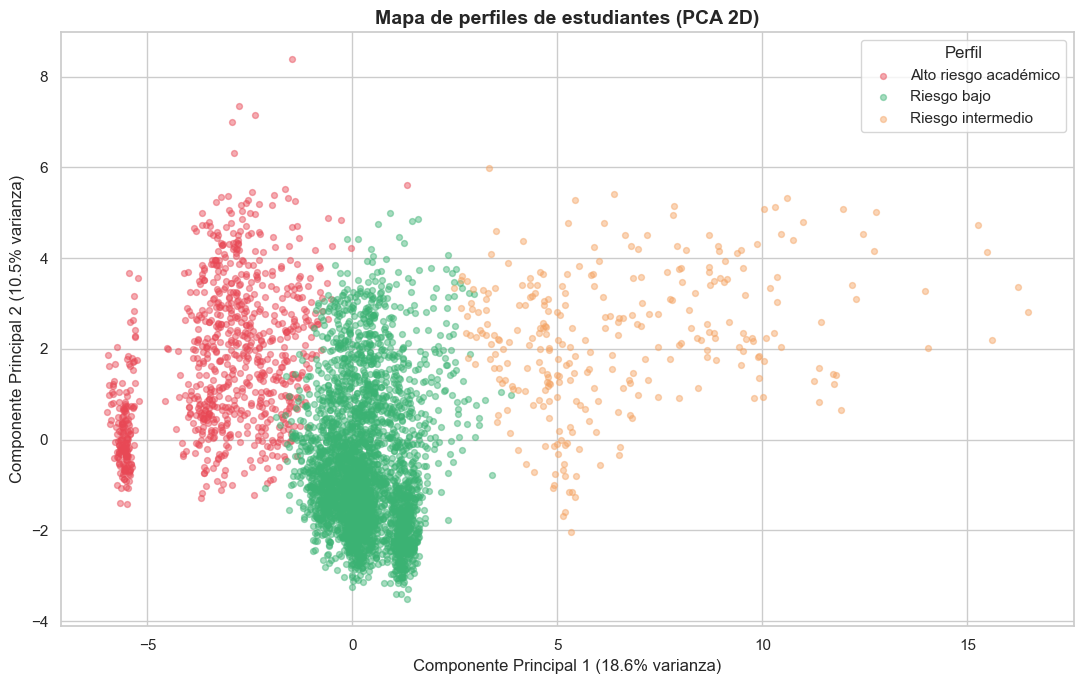

In [41]:
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_kmeans)

df["PC1"] = components[:, 0]
df["PC2"] = components[:, 1]

fig, ax = plt.subplots(figsize=(11, 7))

for idx, name in enumerate(df["Cluster_Name"].dropna().unique()):
    mask = df["Cluster_Name"] == name
    ax.scatter(
        df.loc[mask, "PC1"],
        df.loc[mask, "PC2"],
        alpha=0.45,
        s=18,
        label=name,
        color=PALETTE[idx % len(PALETTE)]
    )

ax.set_title("Mapa de perfiles de estudiantes (PCA 2D)", fontsize=14, fontweight="bold")
ax.set_xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0] * 100:.1f}% varianza)")
ax.set_ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1] * 100:.1f}% varianza)")
ax.legend(title="Perfil", loc="upper right")

plt.tight_layout()
plt.savefig("../outputs/figures/pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


## 5.4 Evaluación de modelos supervisados

A continuación se evalúan los modelos supervisados utilizados para la predicción de abandono escolar:

- Red Neuronal
- Random Forest

Ambos modelos utilizan la variable objetivo `Target_binary` y un conjunto de prueba equivalente al 20% de los datos.


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler_model = StandardScaler()
X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (3539, 34)
Testing shape: (885, 34)


## 5.5 Red Neuronal

La Red Neuronal se utiliza como modelo supervisado para capturar relaciones no lineales entre las variables del dataset y la probabilidad de abandono escolar.


In [43]:
tf.random.set_seed(42)

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred_prob_nn = model.predict(X_test_scaled).ravel()
y_pred_nn = (y_pred_prob_nn > 0.5).astype(int)

accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn)
recall_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)
auc_nn = roc_auc_score(y_test, y_pred_prob_nn)

print("Neural Network Accuracy:", accuracy_nn)
print(classification_report(y_test, y_pred_nn))


Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5399 - loss: 0.7350 - val_accuracy: 0.8065 - val_loss: 0.4607
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step - accuracy: 0.8312 - loss: 0.4015 - val_accuracy: 0.8517 - val_loss: 0.3814
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - accuracy: 0.8674 - loss: 0.3350 - val_accuracy: 0.8630 - val_loss: 0.3570
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step - accuracy: 0.8769 - loss: 0.3114 - val_accuracy: 0.8701 - val_loss: 0.3474
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - accuracy: 0.8785 - loss: 0.2985 - val_accuracy: 0.8771 - val_loss: 0.3434
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.8817 - loss: 0.2902 - val_accuracy: 0.8785 - val_loss: 0.3417
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step - accuracy: 0.8867 - loss: 0.2842 - val_accuracy: 0.8785 - val_loss: 0.3408
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - accuracy: 0.8880 - loss: 0.2794 - val_accuracy: 0.87

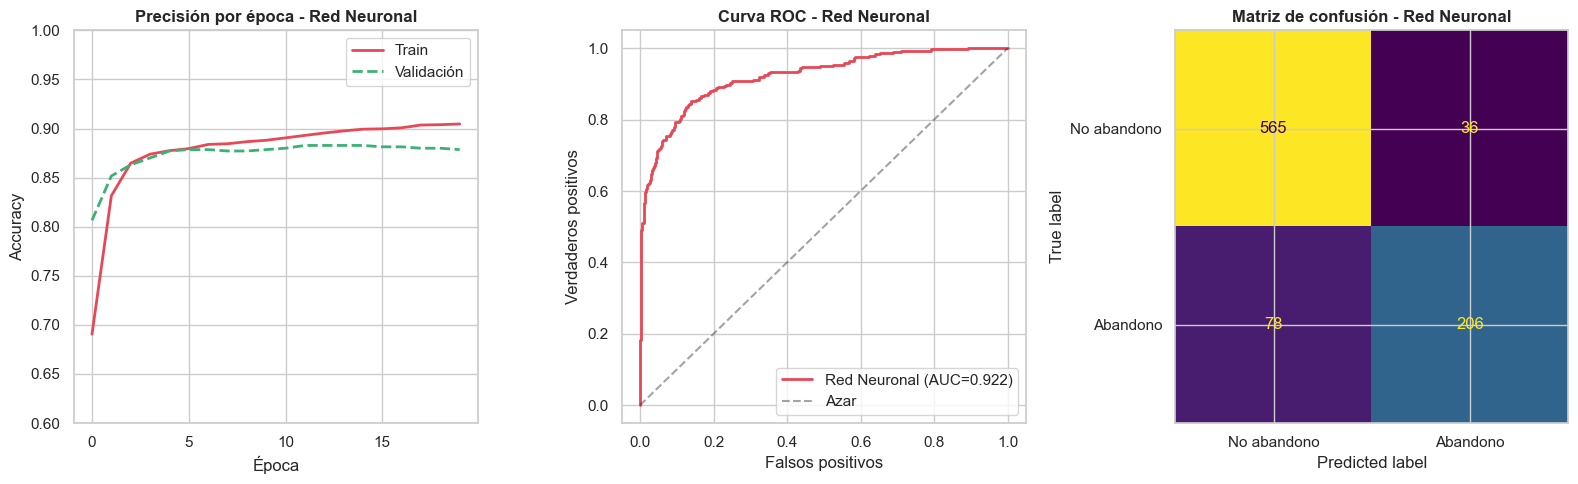

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(history.history["accuracy"], label="Train", color=PALETTE[0], linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Validación", color=PALETTE[1], linewidth=2, linestyle="--")
axes[0].set_title("Precisión por época - Red Neuronal", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].set_ylim([0.6, 1.0])

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_pred_prob_nn)
axes[1].plot(fpr_nn, tpr_nn, color=PALETTE[0], linewidth=2, label=f"Red Neuronal (AUC={auc_nn:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Azar")
axes[1].set_title("Curva ROC - Red Neuronal", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Falsos positivos")
axes[1].set_ylabel("Verdaderos positivos")
axes[1].legend()

cm_nn = confusion_matrix(y_test, y_pred_nn)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=["No abandono", "Abandono"])
disp_nn.plot(ax=axes[2], colorbar=False)
axes[2].set_title("Matriz de confusión - Red Neuronal", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/model_evaluation_neural_network.png", dpi=150, bbox_inches="tight")
plt.show()


## 5.6 Random Forest

Random Forest se utiliza como modelo supervisado robusto para clasificación.  
Este modelo es adecuado para datos tabulares y permite evaluar la importancia relativa de las variables predictoras.


In [45]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_prob_rf)

print("Random Forest Accuracy:", accuracy_rf)
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.880225988700565
              precision    recall  f1-score   support

           0       0.88      0.95      0.92       601
           1       0.87      0.73      0.80       284

    accuracy                           0.88       885
   macro avg       0.88      0.84      0.86       885
weighted avg       0.88      0.88      0.88       885



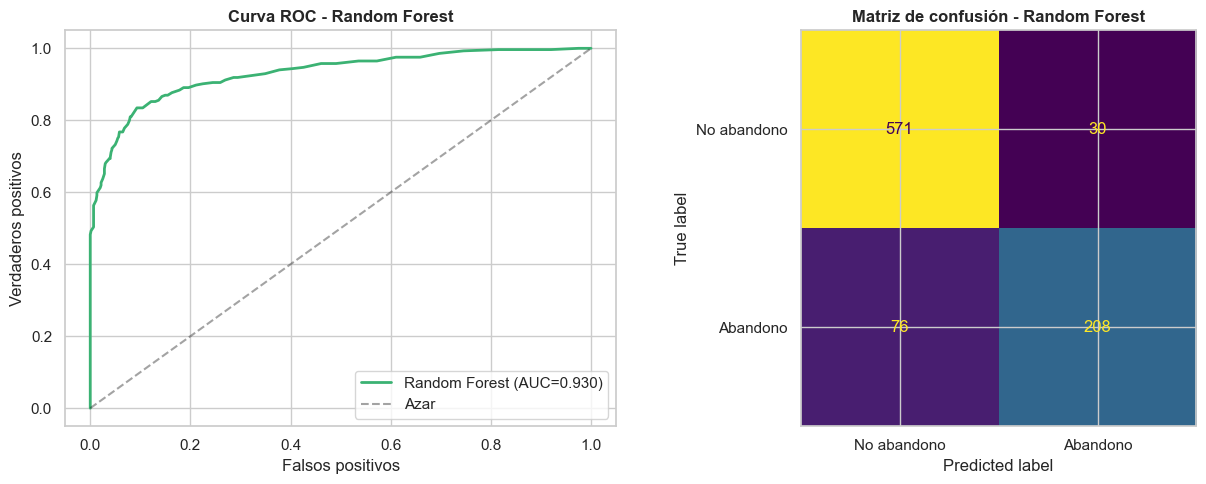

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)
axes[0].plot(fpr_rf, tpr_rf, color=PALETTE[1], linewidth=2, label=f"Random Forest (AUC={auc_rf:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Azar")
axes[0].set_title("Curva ROC - Random Forest", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Falsos positivos")
axes[0].set_ylabel("Verdaderos positivos")
axes[0].legend()

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No abandono", "Abandono"])
disp_rf.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Matriz de confusión - Random Forest", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/model_evaluation_random_forest.png", dpi=150, bbox_inches="tight")
plt.show()


## 5.7 Comparación de modelos

Los modelos supervisados obtuvieron resultados consistentes y adecuados para el problema de predicción de abandono escolar.  
La Red Neuronal permitió capturar relaciones no lineales entre las variables, mientras que Random Forest presentó un desempeño estable y una interpretación más directa mediante importancia de variables.


In [47]:
model_metrics = pd.DataFrame({
    "Modelo": ["Red Neuronal", "Random Forest"],
    "Accuracy": [accuracy_nn, accuracy_rf],
    "Precision_Abandono": [precision_nn, precision_rf],
    "Recall_Abandono": [recall_nn, recall_rf],
    "F1_Abandono": [f1_nn, f1_rf],
    "AUC_ROC": [auc_nn, auc_rf]
})

model_metrics = model_metrics.round(4)
model_metrics.to_csv("../outputs/tables/model_metrics.csv", index=False)

model_metrics


,Modelo,Accuracy,Precision_Abandono,Recall_Abandono,F1_Abandono,AUC_ROC
0,Red Neuronal,0.8712,0.8512,0.7254,0.7833,0.9218
1,Random Forest,0.8802,0.8739,0.7324,0.7969,0.9300


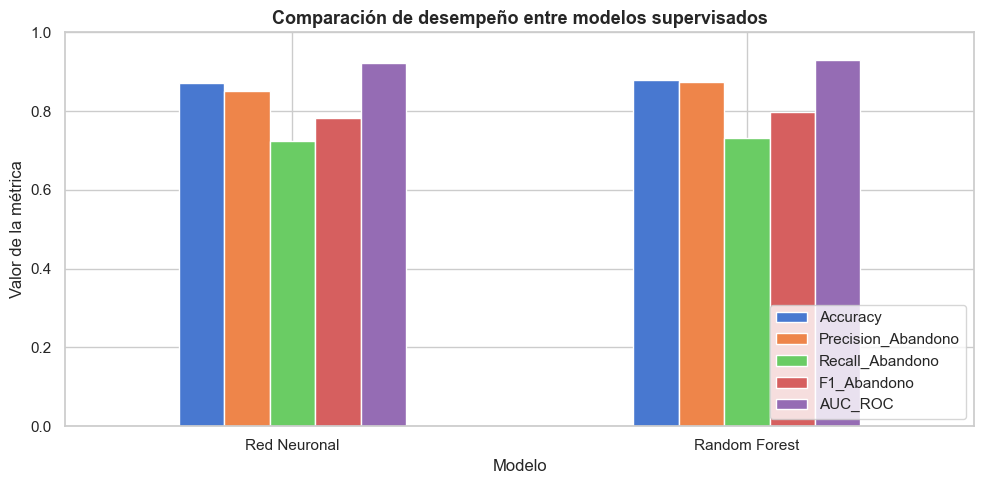

In [48]:
fig, ax = plt.subplots(figsize=(10, 5))

metrics_plot = model_metrics.set_index("Modelo")[["Accuracy", "Precision_Abandono", "Recall_Abandono", "F1_Abandono", "AUC_ROC"]]
metrics_plot.plot(kind="bar", ax=ax)

ax.set_title("Comparación de desempeño entre modelos supervisados", fontsize=13, fontweight="bold")
ax.set_ylabel("Valor de la métrica")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../outputs/figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 5.8 Variables más influyentes

Para complementar la interpretación del modelo Random Forest, se analizan las variables con mayor importancia relativa.  
Estas variables ayudan a identificar factores asociados al abandono escolar y apoyan la generación de recomendaciones de negocio.


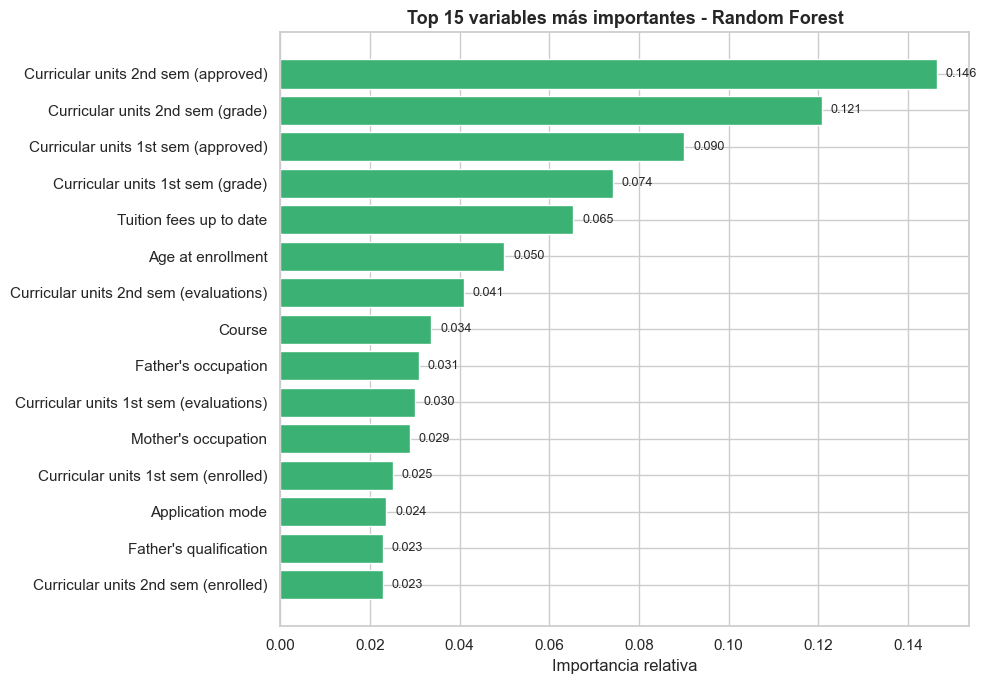

,Variable,Importance
28,Curricular units 2nd sem (approved),0.146391
29,Curricular units 2nd sem (grade),0.120766
22,Curricular units 1st sem (approved),0.090139
23,Curricular units 1st sem (grade),0.074120
14,Tuition fees up to date,0.065332
17,Age at enrollment,0.049891
27,Curricular units 2nd sem (evaluations),0.040935
3,Course,0.033597
10,Father's occupation,0.030907
21,Curricular units 1st sem (evaluations),0.029935


In [49]:
feature_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.to_csv("../outputs/tables/feature_importance.csv", index=False)

top15 = feature_importance.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15["Variable"][::-1], top15["Importance"][::-1], color=PALETTE[1])

ax.set_xlabel("Importancia relativa")
ax.set_title("Top 15 variables más importantes - Random Forest", fontsize=13, fontweight="bold")

for bar, val in zip(bars, top15["Importance"][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

top15


## 5.9 Mapa de riesgo por perfil

El siguiente mapa combina el tamaño de cada segmento con su tasa de abandono.  
Esto permite priorizar perfiles donde el riesgo es alto y el número de estudiantes afectados puede justificar acciones institucionales.


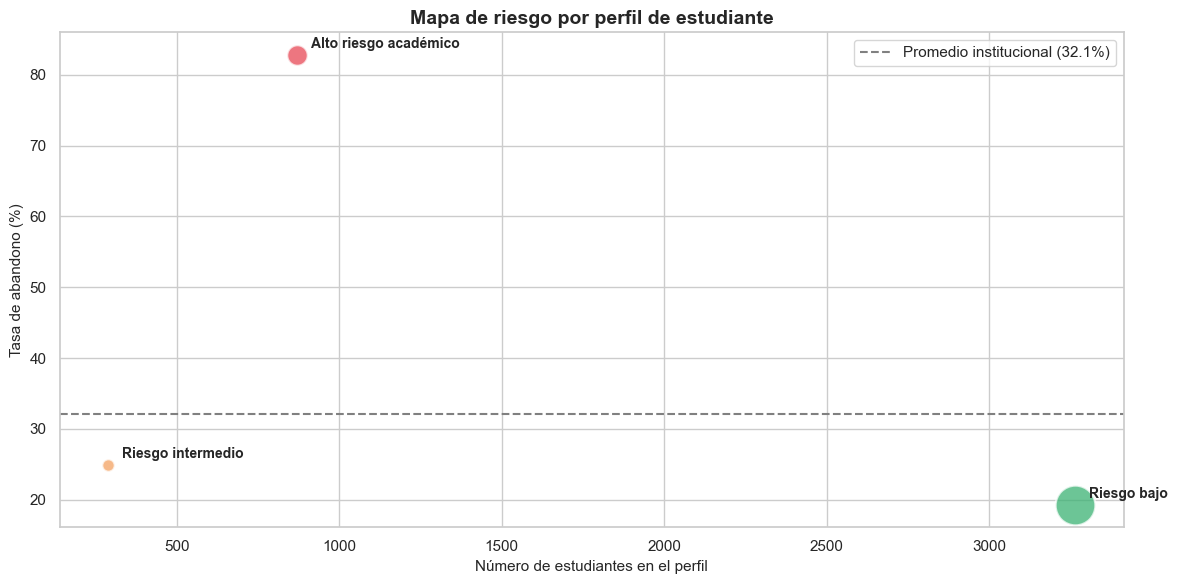

In [50]:
risk_map = cluster_summary.reset_index().rename(columns={"Cluster_Name": "Perfil"})

fig, ax = plt.subplots(figsize=(12, 6))

for idx, row in risk_map.iterrows():
    ax.scatter(
        row["Estudiantes"],
        row["Desercion_%"],
        s=max(row["Estudiantes"] / 4, 80),
        color=PALETTE[idx % len(PALETTE)],
        alpha=0.75,
        edgecolors="white",
        linewidth=1.5
    )
    ax.annotate(
        row["Perfil"],
        (row["Estudiantes"], row["Desercion_%"]),
        textcoords="offset points",
        xytext=(10, 5),
        fontsize=10,
        fontweight="bold"
    )

avg = df["Target_binary"].mean() * 100
ax.axhline(avg, color="gray", linestyle="--", label=f"Promedio institucional ({avg:.1f}%)")
ax.set_xlabel("Número de estudiantes en el perfil", fontsize=11)
ax.set_ylabel("Tasa de abandono (%)", fontsize=11)
ax.set_title("Mapa de riesgo por perfil de estudiante", fontsize=14, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/risk_map.png", dpi=150, bbox_inches="tight")
plt.show()


## 5.10 Recomendaciones de negocio

A partir de los resultados obtenidos mediante los modelos supervisados y la segmentación exploratoria, se identificaron diferentes factores asociados al abandono escolar. Las principales variables relacionadas con la deserción fueron el desempeño académico, el número de materias aprobadas, las calificaciones semestrales y el estado de pagos escolares.

### Prioridad alta: estudiantes con alto riesgo académico

- Implementar sistemas de alerta temprana para estudiantes con bajo desempeño académico durante el primer y segundo semestre.
- Dar seguimiento prioritario a estudiantes con pocas materias aprobadas o calificaciones inferiores al promedio institucional.
- Fortalecer programas de tutorías académicas y acompañamiento personalizado.
- Monitorear estudiantes con adeudos o dificultades relacionadas con pagos escolares.

### Prioridad media: estudiantes con señales parciales de riesgo

- Realizar seguimiento preventivo mediante evaluaciones periódicas.
- Promover asesorías académicas y orientación estudiantil.
- Identificar posibles factores externos relacionados con edad, situación familiar o carga académica.

### Prioridad baja: estudiantes con buen desempeño

- Mantener programas de becas y estímulos académicos.
- Utilizar este grupo como referencia para identificar prácticas asociadas a la permanencia estudiantil.
- Fortalecer programas de reconocimiento y retención institucional.


## 5.11 Resumen ejecutivo

A continuación se presenta un resumen ejecutivo de los principales hallazgos obtenidos durante el análisis. Se incluyen métricas generales del desempeño de los modelos supervisados, perfiles de riesgo identificados mediante segmentación y variables con mayor influencia en la predicción del abandono escolar.

Este resumen permite sintetizar los resultados más relevantes del proyecto y facilitar su interpretación desde una perspectiva institucional y de negocio.

In [51]:
best_model_name = model_metrics.sort_values("F1_Abandono", ascending=False).iloc[0]["Modelo"]
best_accuracy = model_metrics.sort_values("F1_Abandono", ascending=False).iloc[0]["Accuracy"]

highest_risk_profile = cluster_summary.sort_values("Desercion_%", ascending=False).index[0]
highest_risk_rate = cluster_summary.sort_values("Desercion_%", ascending=False).iloc[0]["Desercion_%"]

top_feature = feature_importance.iloc[0]["Variable"]

resumen = pd.DataFrame({
    "Hallazgo": [
        "Tasa de abandono institucional",
        "Perfil de mayor riesgo",
        "Modelo con mejor balance para abandono",
        "Accuracy del mejor modelo",
        "Variable más importante en Random Forest",
        "Modelos supervisados evaluados",
        "Perfiles exploratorios identificados",
    ],
    "Resultado": [
        f"{df['Target_binary'].mean() * 100:.1f}% del total de estudiantes",
        f"{highest_risk_profile} — {highest_risk_rate:.1f}% abandono",
        best_model_name,
        f"{best_accuracy * 100:.1f}%",
        top_feature,
        "Red Neuronal y Random Forest",
        "3 perfiles mediante K-Means",
    ]
})

resumen.to_csv("../outputs/tables/executive_summary.csv", index=False)

display(
    resumen.style
    .set_caption("Resumen Ejecutivo — Predicción de Abandono Estudiantil")
    .set_properties(**{"text-align": "left"})
    .hide(axis="index")
)


Hallazgo,Resultado
Tasa de abandono institucional,32.1% del total de estudiantes
Perfil de mayor riesgo,Alto riesgo académico — 82.8% abandono
Modelo con mejor balance para abandono,Random Forest
Accuracy del mejor modelo,88.0%
Variable más importante en Random Forest,Curricular units 2nd sem (approved)
Modelos supervisados evaluados,Red Neuronal y Random Forest
Perfiles exploratorios identificados,3 perfiles mediante K-Means


## 5.12 Conclusiones finales

Los resultados obtenidos demuestran que las técnicas de Machine Learning permiten analizar y predecir de manera efectiva el abandono escolar utilizando variables académicas, financieras y demográficas.

Los modelos supervisados implementados alcanzaron resultados consistentes y precisiones cercanas al 88%, destacando Random Forest como el modelo con mejor desempeño general, con un Accuracy aproximado de 88.0% y un AUC ROC cercano a 0.93. Asimismo, la Red Neuronal mostró resultados competitivos y una buena capacidad para capturar relaciones complejas entre variables.

Adicionalmente, la implementación de K-Means permitió complementar el análisis mediante la segmentación de estudiantes en perfiles de riesgo diferenciados. Esta segmentación facilitó la interpretación de patrones de comportamiento y permitió identificar grupos prioritarios para intervención institucional.

Los hallazgos obtenidos indican que el rendimiento académico y el avance escolar son los factores más relacionados con la deserción estudiantil. De igual forma, variables asociadas a situación financiera y contexto familiar también mostraron influencia relevante en el problema analizado.

En términos generales, el proyecto demuestra el potencial del Machine Learning como herramienta de apoyo para la toma de decisiones académicas, permitiendo desarrollar estrategias preventivas orientadas a mejorar la permanencia estudiantil y reducir la deserción escolar.